# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window



## Creamos la sesión de spark

In [2]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [4]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [5]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [6]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [7]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

In [3]:
!pip install kafka-python

In [10]:
from pyspark.sql.functions import col, avg, min, max, count, desc, row_number, spark_partition_id, lit, when, window, date_trunc
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
from pyspark.sql.types import StructType, StructField, StringType, DoubleType
from pyspark.sql.functions import from_json, col

# 1. Definimos el esquema EXACTO de tu producer
jsonSchema = StructType([
    StructField("sensor_id", StringType(), True),
    StructField("value", DoubleType(), True),
    StructField("temperature", DoubleType(), True),
    StructField("humidity", DoubleType(), True),
    StructField("status", StringType(), True),
    StructField("timestamp", DoubleType(), True),
    StructField("uuid", StringType(), True)
])

# 2. Leemos de Kafka en modo BATCH usando el tópico "sensores"
df_raw = spark.read \
    .format("kafka") \
    .option("kafka.bootstrap.servers", "kafka:9092") \
    .option("subscribe", "sensores") \
    .option("startingOffsets", "earliest") \
    .load()

# 3. Transformamos el JSON a columnas
df = df_raw.selectExpr("CAST(value AS STRING)") \
    .select(from_json("value", jsonSchema).alias("data")) \
    .select("data.*")

# 4. (IMPORTANTE) Creamos 'event_time' real para que funcione el Ejercicio 7
df = df.withColumn("event_time", col("timestamp").cast("timestamp"))

print("¡Datos cargados correctamente del tópico 'sensores'!")
df.printSchema()
df.show(5)

¡Datos cargados correctamente del tópico 'sensores'!
root
 |-- sensor_id: string (nullable = true)
 |-- value: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- status: string (nullable = true)
 |-- timestamp: double (nullable = true)
 |-- uuid: string (nullable = true)
 |-- event_time: timestamp (nullable = true)

+---------+-----+-----------+--------+------+--------------------+--------------------+--------------------+
|sensor_id|value|temperature|humidity|status|           timestamp|                uuid|          event_time|
+---------+-----+-----------+--------+------+--------------------+--------------------+--------------------+
|       S2|26.83|      77.51|    65.6|  FAIL|1.7656659746953163E9|86fc35c1-4556-460...|2025-12-13 22:46:...|
|       S4|19.86|      61.21|   37.94|  FAIL|1.7656659760643606E9|b5b3eda5-0c34-404...|2025-12-13 22:46:...|
|       S3|11.44|      73.22|   76.88|  WARN| 1.765665977066085E9|b3713c9b-

### Ejercicio 1

In [31]:
# 1. Realiza una exploración básica del DataFrame:
print("--- Esquema ---")
df.printSchema()

print(f"--- Total de filas: {df.count()} ---")

print("--- Total de sensores distintos ---")
num_sensores = df.select("sensor_id").distinct().count()
print(f"Hay {num_sensores} sensores distintos.")

--- Esquema ---
root
 |-- sensor_id: string (nullable = true)
 |-- value: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- status: string (nullable = true)
 |-- timestamp: double (nullable = true)
 |-- uuid: string (nullable = true)
 |-- event_time: timestamp (nullable = true)

--- Total de filas: 781 ---
--- Total de sensores distintos ---
Hay 4 sensores distintos.


### Ejercicio 2

In [33]:
## 2.Crea una columna basada en la diferencia o relación entre dos métricas numéricas del DataFrame.
from pyspark.sql.functions import col, round

# Convertimos Celsius a Fahrenheit
df_transf = df.withColumn("temp_fahrenheit", (col("temperature") * 1.8) + 32)

# Estadísticas para ver la diferencia entre C y F
print("Estadísticas de Temperatura en Fahrenheit:")
df_transf.select(
    round(min("temp_fahrenheit"), 2).alias("Min_F"),
    round(max("temp_fahrenheit"), 2).alias("Max_F"),
    round(avg("temp_fahrenheit"), 2).alias("Media_F")
).show()

Estadísticas de Temperatura en Fahrenheit:
+-----+------+-------+
|Min_F| Max_F|Media_F|
+-----+------+-------+
|68.09|193.89| 131.02|
+-----+------+-------+



### Ejercicio 3

In [35]:
# 3. Filtrado avanzado
# Ajustamos los valores (ej: humidity > 50) según los datos reales
filtro = (col("humidity") > 50) & \
         (col("sensor_id") == "S1")

df_filtrado = df.filter(filtro)

print(f"Registros que cumplen las condiciones: {df_filtrado.count()}")

Registros que cumplen las condiciones: 92


### Ejercicio 4

In [36]:
# 4. Agregaciones por sensor
stats_df = df.groupBy("sensor_id").agg(
    avg("temperature").alias("avg_temp"),
    max("temperature").alias("max_temp"),
    count("*").alias("conteo")
)

stats_df.show()

# Respuesta a las preguntas enunciadas en el apartado 4
print("Sensor con mayor temperatura media:")
stats_df.orderBy(desc("avg_temp")).show(1)

print("Sensor con temperatura máxima más alta:")
stats_df.orderBy(desc("max_temp")).show(1)

+---------+------------------+--------+------+
|sensor_id|          avg_temp|max_temp|conteo|
+---------+------------------+--------+------+
|       S4| 54.11123076923075|    89.9|   195|
|       S3| 54.14004854368933|   89.78|   206|
|       S2| 55.65904761904759|   89.62|   210|
|       S1|56.298529411764676|   89.94|   170|
+---------+------------------+--------+------+

Sensor con mayor temperatura media:
+---------+------------------+--------+------+
|sensor_id|          avg_temp|max_temp|conteo|
+---------+------------------+--------+------+
|       S1|56.298529411764676|   89.94|   170|
+---------+------------------+--------+------+
only showing top 1 row

Sensor con temperatura máxima más alta:
+---------+------------------+--------+------+
|sensor_id|          avg_temp|max_temp|conteo|
+---------+------------------+--------+------+
|       S1|56.298529411764676|   89.94|   170|
+---------+------------------+--------+------+
only showing top 1 row



### Ejercicio 5

In [37]:
# 5. Ranking con funciones de ventana
from pyspark.sql.window import Window
from pyspark.sql.functions import desc, row_number, col

windowSpec = Window.partitionBy("sensor_id").orderBy(desc("value"))

df_ranked = df.withColumn("rank", row_number().over(windowSpec))

# Filtramos para ver el top 1 de cada sensor (el valor más alto registrado)
top_por_sensor = df_ranked.filter(col("rank") == 1)

print("Registro con el valor máximo por cada sensor:")
top_por_sensor.show()

# ¿Cuál es el máximo global?
print("Máximo valor global absoluto:")
top_por_sensor.orderBy(desc("value")).show(1)

Registro con el valor máximo por cada sensor:
+---------+-----+-----------+--------+------+--------------------+--------------------+--------------------+----+
|sensor_id|value|temperature|humidity|status|           timestamp|                uuid|          event_time|rank|
+---------+-----+-----------+--------+------+--------------------+--------------------+--------------------+----+
|       S1|49.66|      73.78|   63.25|  WARN|1.7656661973095844E9|5dcafebc-eaae-44d...|2025-12-13 22:49:...|   1|
|       S2|49.73|      20.07|   73.26|    OK|1.7656664485781767E9|b6d54752-70a4-4e2...|2025-12-13 22:54:...|   1|
|       S3|49.96|      62.19|    87.4|  WARN|1.7656665486789207E9|bc6c8a56-be15-490...|2025-12-13 22:55:...|   1|
|       S4| 49.8|      44.87|    27.2|  WARN|1.7656666627537346E9|441c0a6a-aa6a-4cc...|2025-12-13 22:57:...|   1|
+---------+-----+-----------+--------+------+--------------------+--------------------+--------------------+----+

Máximo valor global absoluto:
+---------+

### Ejercicio 6

In [38]:
# 6. Join con tabla auxiliar
# Creamos un DF auxiliar ficticio
data_aux = [("S1", "Laboratorio"), ("S2", "Exteriores"), ("S3", "Almacen")]
cols_aux = ["sensor_id", "ubicacion"]
df_ubicacion = spark.createDataFrame(data_aux, cols_aux)

# Hacemos el join
df_unido = df.join(df_ubicacion, on="sensor_id", how="left")

print("Primeros 5 registros unidos:")
df_unido.show(5)

Primeros 5 registros unidos:
+---------+-----+-----------+--------+------+--------------------+--------------------+--------------------+----------+
|sensor_id|value|temperature|humidity|status|           timestamp|                uuid|          event_time| ubicacion|
+---------+-----+-----------+--------+------+--------------------+--------------------+--------------------+----------+
|       S4|19.86|      61.21|   37.94|  FAIL|1.7656659760643606E9|b5b3eda5-0c34-404...|2025-12-13 22:46:...|      NULL|
|       S3|11.44|      73.22|   76.88|  WARN| 1.765665977066085E9|b3713c9b-ebcf-4ab...|2025-12-13 22:46:...|   Almacen|
|       S3|44.11|      20.99|    55.5|    OK|1.7656659790697021E9|93793bdf-8122-4d1...|2025-12-13 22:46:...|   Almacen|
|       S2|26.83|      77.51|    65.6|  FAIL|1.7656659746953163E9|86fc35c1-4556-460...|2025-12-13 22:46:...|Exteriores|
|       S2|26.06|      61.19|    59.7|  FAIL|1.7656659800702147E9|40d4c6cf-45c9-4e7...|2025-12-13 22:46:...|Exteriores|
+---------+

### Ejercicio 7

In [39]:
# 7. Agrupación por ventana temporal
from pyspark.sql.functions import window, col, count, avg

df_ventana = df.groupBy(window(col("event_time"), "1 minute")).agg(
    count("*").alias("num_eventos"),
    avg("humidity").alias("humedad_media")
)

df_ventana.withColumn("inicio_ventana", col("window.start")) \
          .select("inicio_ventana", "num_eventos", "humedad_media") \
          .orderBy("inicio_ventana") \
          .show(5, truncate=False)

+-------------------+-----------+------------------+
|inicio_ventana     |num_eventos|humedad_media     |
+-------------------+-----------+------------------+
|2025-12-13 22:46:00|45         |56.3188888888889  |
|2025-12-13 22:47:00|60         |54.58683333333335 |
|2025-12-13 22:48:00|60         |48.38033333333333 |
|2025-12-13 22:49:00|60         |59.807999999999986|
|2025-12-13 22:50:00|60         |54.70299999999998 |
+-------------------+-----------+------------------+
only showing top 5 rows



### Ejercicio 8

In [26]:
# 8. Repartición y particiones
# Repartimos por sensor_id
df_repartido = df.repartition("sensor_id")

# Añadimos ID de partición para ver dónde cae cada dato
df_part = df_repartido.withColumn("partition_id", spark_partition_id())

print("Distribución de registros por partición:")
df_part.groupBy("partition_id").count().show()

Distribución de registros por partición:
+------------+-----+
|partition_id|count|
+------------+-----+
|           0|  781|
+------------+-----+



### Ejercicio 9

In [40]:
# 9. Detección de anomalías
# Criterio: Si la temperatura supera 30 grados
df_anomalia = df.withColumn("es_anomalia", 
                             when(col("temperature") > 30, 1).otherwise(0))

anomalos_total = df_anomalia.filter(col("es_anomalia") == 1).count()
print(f"Total registros anómalos: {anomalos_total}")

print("Sensor con más anomalías:")
df_anomalia.filter(col("es_anomalia") == 1) \
           .groupBy("sensor_id") \
           .count() \
           .orderBy(desc("count")) \
           .show(1)

Total registros anómalos: 688
Sensor con más anomalías:
+---------+-----+
|sensor_id|count|
+---------+-----+
|       S2|  189|
+---------+-----+
only showing top 1 row



### Ejercicio 10

In [29]:
# 10. Cruce de métricas
from pyspark.sql.functions import col, desc

# Fórmula: 50% del valor del sensor + 30% temperatura + 20% humedad
df_score = df.withColumn("score", 
                         (col("value") * 0.5) + 
                         (col("temperature") * 0.3) + 
                         (col("humidity") * 0.2))

print("Sensor con puntuación más alta:")
df_score.select("sensor_id", "score").orderBy(desc("score")).show(1)

# Ver algunos registros más para comprobar el cálculo
print("Primeros 5 registros con sus puntuaciones:")
df_score.select("sensor_id", "value", "temperature", "humidity", "score").show(5)

Sensor con puntuación más alta:
+---------+-----------------+
|sensor_id|            score|
+---------+-----------------+
|       S4|67.15100000000001|
+---------+-----------------+
only showing top 1 row

Primeros 5 registros con sus puntuaciones:
+---------+-----+-----------+--------+------+
|sensor_id|value|temperature|humidity| score|
+---------+-----+-----------+--------+------+
|       S2|26.83|      77.51|    65.6|49.788|
|       S4|19.86|      61.21|   37.94|35.881|
|       S3|11.44|      73.22|   76.88|43.062|
|       S1|26.12|      72.31|   69.14|48.581|
|       S3|44.11|      20.99|    55.5|39.452|
+---------+-----+-----------+--------+------+
only showing top 5 rows



### Ejercicio 11

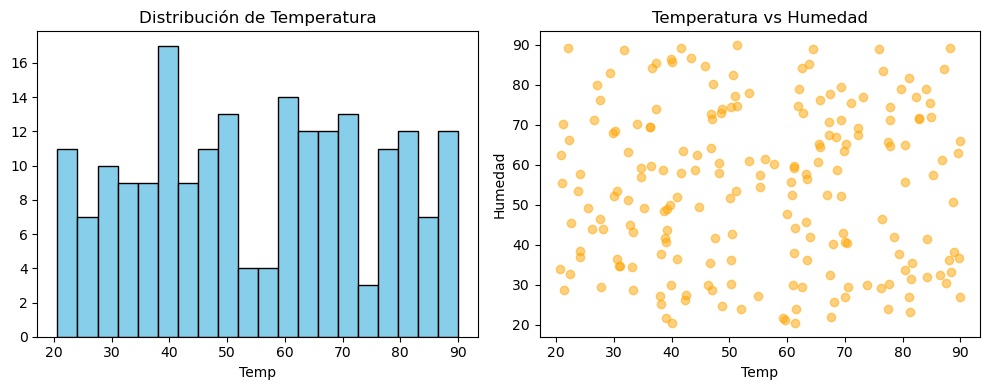

In [41]:
# 11. Gráficar DF
# Tomamos una muestra (o el DF completo si es pequeño) a Pandas
pdf = df.select("temperature", "humidity").limit(200).toPandas()

# Gráfico 1: Histograma de Temperatura
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(pdf["temperature"], bins=20, color='skyblue', edgecolor='black')
plt.title("Distribución de Temperatura")
plt.xlabel("Temp")

# Gráfico 2: Scatter plot Temp vs Humedad
plt.subplot(1, 2, 2)
plt.scatter(pdf["temperature"], pdf["humidity"], alpha=0.5, color='orange')
plt.title("Temperatura vs Humedad")
plt.xlabel("Temp")
plt.ylabel("Humedad")

plt.tight_layout()
plt.show()